# 🏎️ Nina's F1 Predictions: 2026 Japanese Grand Prix (Round 3)
## Suzuka Circuit — March 27-29, 2026

**Model version:** v1.0 (Complete race engineer model)  
**Data:** 72 races (2023-2026), 1,442 results + lap telemetry + weather  
**Last updated:** March 27, 2026 at 11:00 PM MT

### What This Is

A machine learning model that predicts Formula 1 race results and optimizes F1 Fantasy lineups. The model analyzes 24 different factors — the same kinds of data a race engineer would consider when building a race strategy — and runs 10,000 simulated races to estimate each driver's probability of finishing on the podium, in the points, or beating their teammate.

The 2026 season introduced **massive regulation changes** — new power units (50/50 electric/ICE), active aerodynamics that replace DRS, smaller and lighter cars, and 100% sustainable fuels. The entire competitive order has been reshuffled. Mercedes went from struggling to dominant. McLaren went from champions to backmarkers. Red Bull went from winning everything to Tier 4. This model accounts for that by weighting 2026 data 10x more heavily than historical data.

### The 24 Features

The model looks at every driver through these lenses:

**Car Performance (2026 only):**
- 🏗️ Constructor pace — average finish position by team this season
- ⚡ Straight-line speed — speed trap data, critical for Suzuka's 1.2km back straight

**Driver Skill (all years, car-independent):**
- 👤 Teammate delta — how much better/worse than their teammate
- 📊 Recent form — rolling average finish position
- 🚀 First lap performance — who consistently gains/loses positions at the start
- 📈 Season momentum — are they trending up or down? (uses current team only for drivers who switched)
- 🎯 Positions gained per race — racecraft and overtaking ability
- ⏱️ Qualifying vs race pace — "Saturday car" vs "Sunday car"

**Tire & Strategy:**
- 🛞 Tire degradation rate — who's gentle on tires (longer stints, fewer stops)
- 🔧 Pit stop frequency — driver and team pit stop patterns

**Track-Specific (Suzuka):**
- 🗾 Sector 1 pace — technical corners through The Esses
- 🗾 Sector 2 pace — power sector (back straight + Degner curves)
- 🗾 Sector 3 pace — mixed character (Spoon, 130R, chicane)
- 🏁 Track experience — how many times they've raced here

**Conditions & Context:**
- 🌡️ Weather — temperature, humidity, rainfall
- 🌧️ Wet-weather skill — positions gained in historical rain races
- 🟡 Safety car — 33% probability at Suzuka, wired into simulations
- 🔄 Team changed — 9 of 22 drivers switched teams for 2026 (adds uncertainty)
- 📋 Consistency — lap time variation (lower = more reliable)
- 🏎️ DNF rate — reliability factor
- 🔬 2026 flag — tells the model this is a regulation-change year

### How It Works

1. **Two-model approach:** Car pace comes ONLY from 2026 data. Driver skill uses all 72 races but measures performance relative to the car — so it transfers across regulation changes.
2. **XGBoost machine learning** — the gold standard algorithm for F1 prediction (77-82% winner accuracy in published research). It automatically learns which features matter most.
3. **10,000 simulated races** — each simulation adds realistic randomness (safety cars, incidents, mechanical failures) calibrated to the model's actual prediction error. This produces probabilities, not just a single prediction.
4. **Honest validation** — we use leave-one-out cross-validation on 2026 data. The accuracy we report (MAE 2.39 positions) is real — the model never saw the data it was tested on.

**Important:** Qualifying hasn't happened yet, so grid positions are estimated. After Saturday qualifying, these predictions will be re-run with actual grid positions — the single biggest accuracy improvement available.


In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

df = pd.read_csv('../data/all_results.csv')
weather = pd.read_csv('../data/weather.csv')
lap_stats = pd.read_csv('../data/lap_stats.csv')
advanced = pd.read_csv('../data/advanced_features.csv')

df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df['DNF'] = df['Status'].apply(lambda x: 0 if x == 'Finished' or (isinstance(x,str) and 'Lap' in x) else 1)
df = df.sort_values(['Year','Round']).reset_index(drop=True)
df = df.merge(weather[['Year','Round','avg_air_temp','avg_track_temp','avg_humidity','avg_wind_speed','had_rain','rain_pct']], on=['Year','Round'], how='left')

# Build driver-level advanced feature lookups
first_lap_avg = advanced.groupby('FullName')['first_lap_gain'].mean().to_dict()
tire_deg_avg = advanced.groupby('FullName')['tire_degradation'].mean().to_dict()
quali_race_gap = advanced.groupby('FullName')['quali_race_gap'].mean().to_dict()

# Momentum: slope of last 5 finishes
momentum = {}
for driver in advanced['FullName'].unique():
    dh = advanced[advanced['FullName']==driver].sort_values(['Year','Round']).tail(5)
    positions = dh['finish'].dropna().values
    if len(positions) >= 3:
        momentum[driver] = np.polyfit(range(len(positions)), positions, 1)[0]
    else:
        momentum[driver] = 0

# Constructor speed + consistency
speeds_2026 = lap_stats[lap_stats['Year']==2026].groupby('Team')['avg_speed_st'].mean().to_dict()
driver_consistency = lap_stats.groupby('FullName')['lap_time_std'].mean().to_dict()

suzuka_adv = advanced[advanced['RaceName'].str.contains('Japan', case=False)]
suzuka_overtake_rate = abs(suzuka_adv['quali_race_gap']).mean()  # avg absolute position changes



## 1. New Feature Deep Dive

Four charts showing what makes each driver unique — their first-lap performance (who gains positions at the start), how gently they treat their tires, whether they're trending up or down this season, and how fast their car is on the straights. These differences matter at Suzuka.


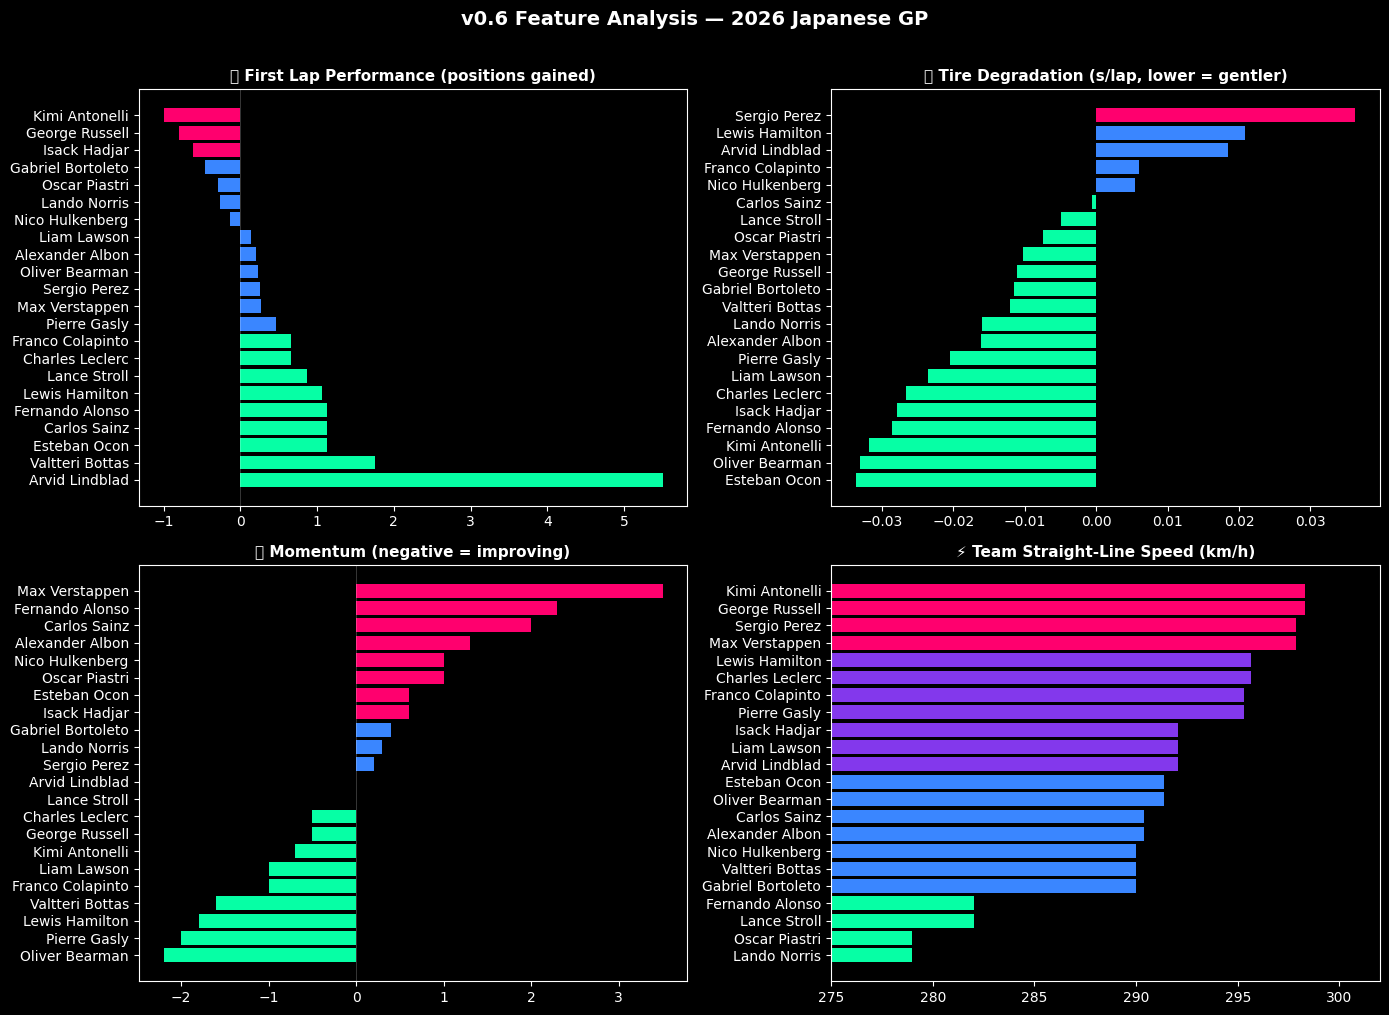

In [2]:
# Visualize the new features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# First lap performance
grid_2026_names = df[df['Year']==2026]['FullName'].unique()
fl_data = {d: first_lap_avg.get(d, 0) for d in grid_2026_names}
fl_sorted = sorted(fl_data.items(), key=lambda x: x[1], reverse=True)
names, vals = zip(*fl_sorted)
colors = ['#06ffa5' if v > 0.5 else '#ff006e' if v < -0.5 else '#3a86ff' for v in vals]
axes[0,0].barh(names, vals, color=colors)
axes[0,0].set_title('🚀 First Lap Performance (positions gained)', fontweight='bold', fontsize=11)
axes[0,0].axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

# Tire degradation
td_data = {d: tire_deg_avg.get(d, 0.05) for d in grid_2026_names}
td_sorted = sorted(td_data.items(), key=lambda x: x[1])
names, vals = zip(*td_sorted)
colors = ['#06ffa5' if v < 0 else '#3a86ff' if v < 0.03 else '#ff006e' for v in vals]
axes[0,1].barh(names, vals, color=colors)
axes[0,1].set_title('🛞 Tire Degradation (s/lap, lower = gentler)', fontweight='bold', fontsize=11)

# Momentum
mom_data = {d: momentum.get(d, 0) for d in grid_2026_names}
mom_sorted = sorted(mom_data.items(), key=lambda x: x[1])
names, vals = zip(*mom_sorted)
colors = ['#06ffa5' if v < -0.5 else '#ff006e' if v > 0.5 else '#3a86ff' for v in vals]
axes[1,0].barh(names, vals, color=colors)
axes[1,0].set_title('📈 Momentum (negative = improving)', fontweight='bold', fontsize=11)
axes[1,0].axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

# Speed traps
spd_data = {d: speeds_2026.get(lap_stats[lap_stats['FullName']==d]['Team'].iloc[0], 290) 
            if len(lap_stats[lap_stats['FullName']==d]) > 0 else 290 for d in grid_2026_names}
spd_sorted = sorted(spd_data.items(), key=lambda x: x[1])
names, vals = zip(*spd_sorted)
colors = ['#ff006e' if v > 296 else '#8338ec' if v > 292 else '#3a86ff' if v > 288 else '#06ffa5' for v in vals]
axes[1,1].barh(names, vals, color=colors)
axes[1,1].set_title('⚡ Team Straight-Line Speed (km/h)', fontweight='bold', fontsize=11)
axes[1,1].set_xlim(275, 302)

plt.suptitle('v0.6 Feature Analysis — 2026 Japanese GP', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/features_v6.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Suzuka Sector Analysis

Suzuka has three distinct sectors that test different car characteristics:
- **S1 (Turns 1-9):** High-speed technical corners through 'The Esses' — rewards downforce and driver confidence
- **S2 (Back straight + Degner):** Pure power — the 1.2km straight is where active aero overtakes happen
- **S3 (Spoon, 130R, chicane):** Mixed character — late braking and car balance


  🗾 SUZUKA SECTOR PROFILES — Who's Fast Where?

  S1: Technical (The Esses) | S2: Power (Back Straight) | S3: Mixed

  Driver                   S1 (tech)   S2 (power)   S3 (mixed)  Best Sector
  ----------------------------------------------------------------------
  George Russell             -0.191s      -0.067s      -0.010s  S1
  Kimi Antonelli             -2.128s      -1.042s      -0.576s  S1
  Charles Leclerc            -0.210s      -0.227s      -0.077s  S2
  Lewis Hamilton             -0.231s      -0.121s      -0.057s  S1
  Lando Norris               -0.503s      -0.354s      -0.079s  S1
  Max Verstappen             -0.584s      -0.487s      -0.154s  S1
  Oliver Bearman             -1.925s      -0.768s      -0.379s  S1
  Arvid Lindblad             no data      no data      no data  No Suzuka data
  Gabriel Bortoleto          -1.586s      -0.641s      -0.396s  S1
  Pierre Gasly               +0.466s      +0.270s      +0.138s  S3
  Esteban Ocon               +0.575s      +0.374s   

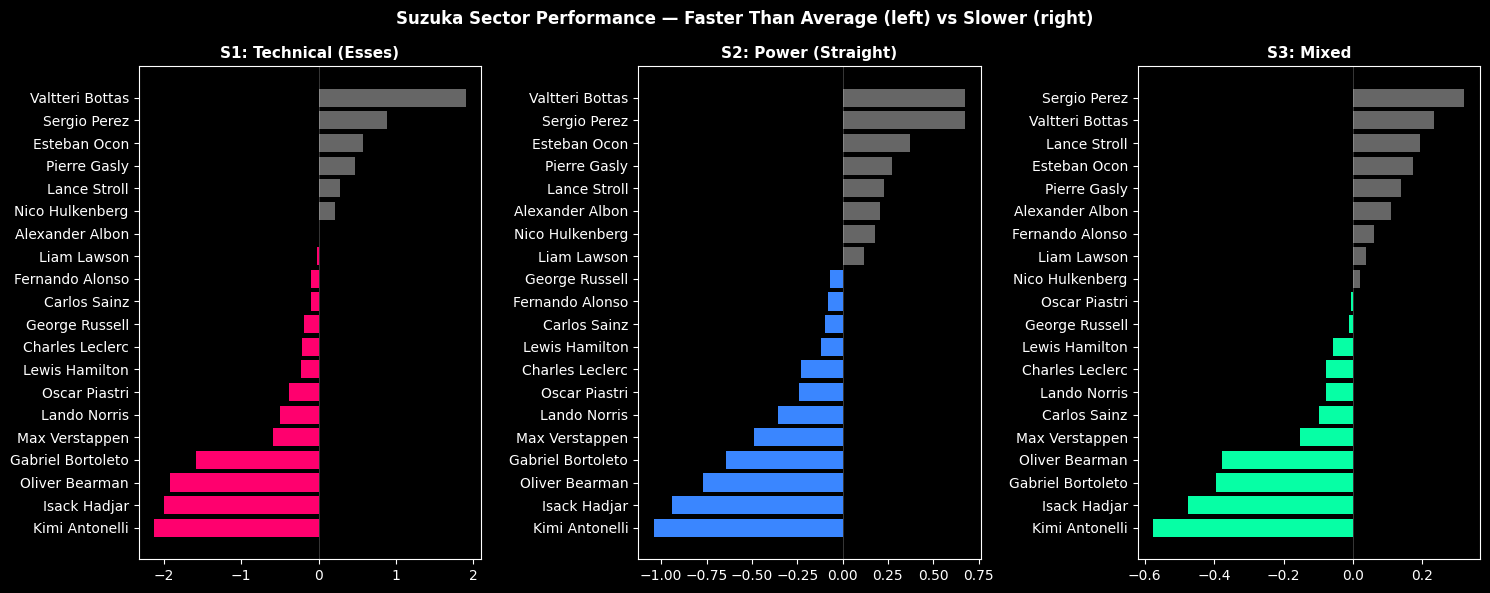

In [3]:
# Suzuka sector profiles
sectors = pd.read_csv('../data/suzuka_sectors.csv')

# Normalize to find relative strengths
driver_sec = sectors.groupby('FullName')[['avg_s1','avg_s2','avg_s3']].mean()
for c in ['avg_s1','avg_s2','avg_s3']:
    driver_sec[f'{c}_delta'] = driver_sec[c] - driver_sec[c].mean()

# Sector strength lookup
sector_s1 = driver_sec['avg_s1_delta'].to_dict()
sector_s2 = driver_sec['avg_s2_delta'].to_dict()
sector_s3 = driver_sec['avg_s3_delta'].to_dict()

# Display for 2026 grid
grid_2026_names = df[df['Year']==2026]['FullName'].unique()
print("=" * 75)
print("  🗾 SUZUKA SECTOR PROFILES — Who's Fast Where?")
print("=" * 75)
print(f"\n  S1: Technical (The Esses) | S2: Power (Back Straight) | S3: Mixed")
print(f"\n  {'Driver':22s}  {'S1 (tech)':>10s}  {'S2 (power)':>11s}  {'S3 (mixed)':>11s}  {'Best Sector'}")
print("  " + "-" * 70)
for d in grid_2026_names:
    if d in driver_sec.index:
        r = driver_sec.loc[d]
        deltas = {'S1':r['avg_s1_delta'],'S2':r['avg_s2_delta'],'S3':r['avg_s3_delta']}
        best = min(deltas, key=deltas.get)
        print(f"  {d:22s}  {r['avg_s1_delta']:>+9.3f}s  {r['avg_s2_delta']:>+10.3f}s  {r['avg_s3_delta']:>+10.3f}s  {best}")
    else:
        print(f"  {d:22s}  {'no data':>10s}  {'no data':>11s}  {'no data':>11s}  No Suzuka data")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
sectors_list = [('avg_s1_delta', 'S1: Technical (Esses)', '#ff006e'),
                ('avg_s2_delta', 'S2: Power (Straight)', '#3a86ff'),
                ('avg_s3_delta', 'S3: Mixed', '#06ffa5')]

for ax, (col, title, color) in zip(axes, sectors_list):
    data = {d: driver_sec.loc[d][col] for d in grid_2026_names if d in driver_sec.index}
    sorted_data = sorted(data.items(), key=lambda x: x[1])
    names, vals = zip(*sorted_data)
    colors = [color if v < 0 else '#666666' for v in vals]
    ax.barh(names, vals, color=colors)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

plt.suptitle('Suzuka Sector Performance — Faster Than Average (left) vs Slower (right)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/suzuka_sectors_v7.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Car Pace (2026 Only)

The most important factor in F1: which car are you driving? This section uses ONLY 2026 results because the new regulations completely reshuffled the pecking order. Mercedes went from struggling to dominant. McLaren went from champions to backmarkers. Historical speed means nothing when the cars are fundamentally different.


  🏗️ CONSTRUCTOR PACE (2026 Only)

  Team                     Avg Fin   Speed  Tier
  --------------------------------------------------
  Mercedes                P   1.5   298  Tier 1
  Ferrari                 P   3.5   296  Tier 2
  Haas F1 Team            P   9.2   291  Tier 3
  Alpine                  P  10.0   295  Tier 3
  Racing Bulls            P  10.0   292  Tier 3
  Red Bull Racing         P  12.5   298  Tier 4
  Williams                P  14.5   290  Tier 4
  Audi                    P  15.8   295  Tier 4
  Cadillac                P  15.8   285  Tier 4
  McLaren                 P  16.2   279  Tier 5
  Aston Martin            P  17.5   282  Tier 5


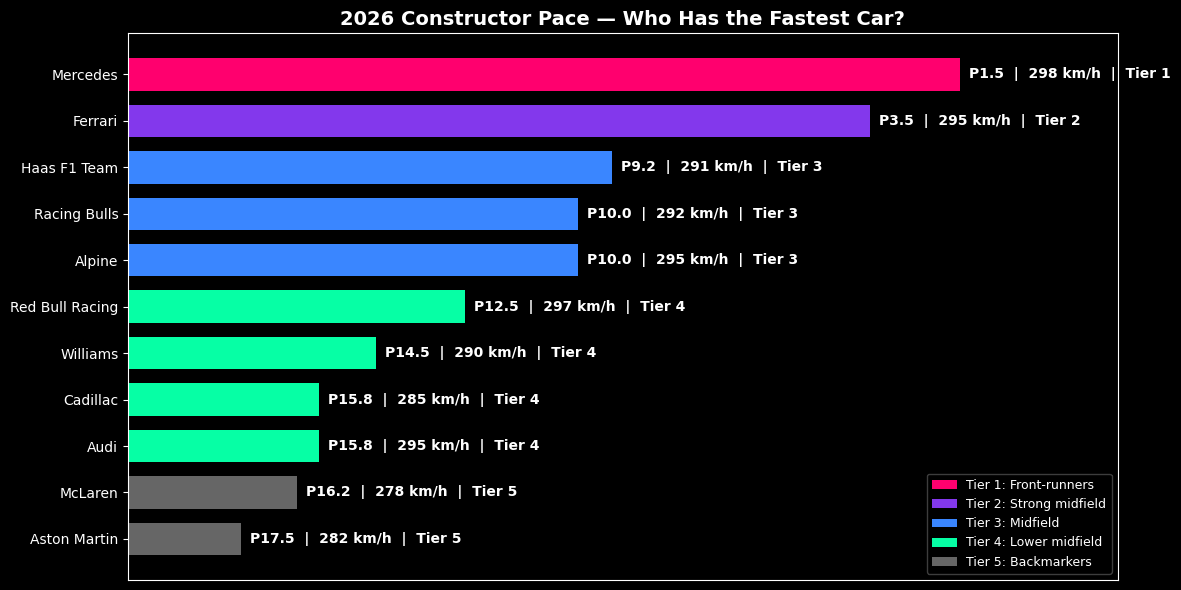

In [4]:
data_2026 = df[df['Year']==2026].copy()
cp = data_2026.groupby('TeamName').agg(avg_finish=('Position','mean'), avg_grid=('GridPosition','mean'), best=('Position','min')).reset_index().sort_values('avg_finish')
car_pace = dict(zip(cp['TeamName'], cp['avg_finish']))
car_speed = {t: speeds_2026.get(t, 290) for t in cp['TeamName']}

def tier(a):
    if a<=3: return 'Tier 1'
    elif a<=7: return 'Tier 2'
    elif a<=12: return 'Tier 3'
    elif a<=16: return 'Tier 4'
    else: return 'Tier 5'

print("=" * 70)
print("  🏗️ CONSTRUCTOR PACE (2026 Only)")
print("=" * 70)
print(f"\n  {'Team':22s}  {'Avg Fin':>8s}  {'Speed':>6s}  {'Tier'}")
print("  " + "-" * 50)
for _, r in cp.iterrows():
    print(f"  {r['TeamName']:22s}  P{r['avg_finish']:>6.1f}  {car_speed.get(r['TeamName'],290):>4.0f}  {tier(r['avg_finish'])}")
# Constructor pace visualization — clear tier separation
fig, ax = plt.subplots(figsize=(12, 6))
cp_sorted = cp.sort_values('avg_finish', ascending=False)
tier_colors = {'Tier 1':'#ff006e','Tier 2':'#8338ec','Tier 3':'#3a86ff','Tier 4':'#06ffa5','Tier 5':'#666666'}
colors = [tier_colors.get(tier(r['avg_finish']), '#999') for _, r in cp_sorted.iterrows()]

# Use finish position as bar length, but start from P20 so P1 is longest
bar_values = [20 - r['avg_finish'] for _, r in cp_sorted.iterrows()]
bars = ax.barh(cp_sorted['TeamName'], bar_values, color=colors, height=0.7)

# Labels on the bars
for bar, (_, r) in zip(bars, cp_sorted.iterrows()):
    speed = int(car_speed.get(r['TeamName'], 290))
    label = f"P{r['avg_finish']:.1f}  |  {speed} km/h  |  {tier(r['avg_finish'])}"
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xlabel('')
ax.set_title('2026 Constructor Pace — Who Has the Fastest Car?', fontsize=14, fontweight='bold')
ax.set_xlim(0, 22)
ax.set_xticks([])  # Hide x-axis numbers — the labels tell the story

# Add tier legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff006e', label='Tier 1: Front-runners'),
    Patch(facecolor='#8338ec', label='Tier 2: Strong midfield'),
    Patch(facecolor='#3a86ff', label='Tier 3: Midfield'),
    Patch(facecolor='#06ffa5', label='Tier 4: Lower midfield'),
    Patch(facecolor='#666666', label='Tier 5: Backmarkers'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('../data/constructor_pace_v10.png', dpi=150, bbox_inches='tight')
plt.show()


## 3b. FP1 Practice Data (Live)

Actual practice session data from Suzuka, pulled via FastF1. This updates car pace and speed estimates with real 2026 Suzuka performance, and provides actual weather conditions for the prediction model.

In [5]:
# ============================================================
# FP1 DATA INTEGRATION
# ============================================================
import fastf1
fastf1.Cache.enable_cache('../data/cache')

fp1 = fastf1.get_session(2026, 'Japan', 'FP1')
fp1.load()
fp1_laps = fp1.laps

# --- FP1 Best Laps ---
fp1_best = fp1_laps.groupby('Driver')['LapTime'].min().sort_values()
fastest = fp1_best.iloc[0].total_seconds()

# Map abbreviations to full names
abbr_map = dict(zip(fp1.results['Abbreviation'], fp1.results['FullName']))
team_map = dict(zip(fp1.results['FullName'], fp1.results['TeamName']))

print('=' * 80)
print('  🏁 FP1 RESULTS — Suzuka (Live Data)')
print('=' * 80)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':16s}  {'Best Lap':>10s}  {'Gap':>8s}  {'Top Spd':>7s}")
print('  ' + '-' * 72)

fp1_pace = {}  # driver -> gap to fastest
fp1_team_pace = {}  # team -> avg gap
fp1_speeds = {}  # driver -> top speed

for pos, (drv, lt) in enumerate(fp1_best.items(), 1):
    if pd.isna(lt): continue
    secs = lt.total_seconds()
    gap = secs - fastest
    name = abbr_map.get(drv, drv)
    team = team_map.get(name, '')
    
    # Speed trap
    drv_laps = fp1_laps[fp1_laps['Driver']==drv]
    top_spd = drv_laps['SpeedST'].max() if 'SpeedST' in drv_laps.columns else np.nan
    
    fp1_pace[name] = gap
    fp1_speeds[name] = top_spd if pd.notna(top_spd) else 290
    
    gap_str = 'FASTEST' if gap == 0 else f'+{gap:.3f}'
    spd_str = f'{top_spd:.0f}' if pd.notna(top_spd) else 'N/A'
    mins = int(secs // 60)
    rem = secs % 60
    print(f'  P{pos:>2d}  {name:22s}  {team:16s}  {mins}:{rem:06.3f}  {gap_str:>8s}  {spd_str:>5s}')

# --- Build team-level FP1 pace ---
fp1_team_gaps = {}
for name, gap in fp1_pace.items():
    team = team_map.get(name, '')
    if team not in fp1_team_gaps:
        fp1_team_gaps[team] = []
    fp1_team_gaps[team].append(gap)

fp1_team_avg = {t: np.mean(gaps) for t, gaps in fp1_team_gaps.items()}
fp1_team_speed = {}
for name, spd in fp1_speeds.items():
    team = team_map.get(name, '')
    if team not in fp1_team_speed:
        fp1_team_speed[team] = []
    fp1_team_speed[team].append(spd)
fp1_team_speed = {t: np.mean(s) for t, s in fp1_team_speed.items()}

# Convert FP1 gaps to estimated race pace positions
# Use FP1 order as position proxy, blended with 2026 race data
fp1_sorted = sorted(fp1_team_avg.items(), key=lambda x: x[1])
fp1_team_pos = {}
for i, (team, gap) in enumerate(fp1_sorted):
    fp1_pos = (i * 2) + 1.5  # spread across grid
    fp1_team_pos[team] = fp1_pos

# Blend: 40% FP1 Suzuka-specific, 60% season results
FP1_WEIGHT = 0.4
print(f'\n  📊 BLENDED CAR PACE (60% season + 40% FP1):')
print(f"  {'Team':22s}  {'Season':>7s}  {'FP1':>5s}  {'Blended':>8s}  {'FP1 Spd':>7s}")
print('  ' + '-' * 55)

car_pace_fp1 = {}
car_speed_fp1 = {}
for team in car_pace:
    season = car_pace[team]
    fp1_p = fp1_team_pos.get(team, season)
    blended = season * (1 - FP1_WEIGHT) + fp1_p * FP1_WEIGHT
    car_pace_fp1[team] = blended
    
    s_spd = car_speed.get(team, 290)
    f_spd = fp1_team_speed.get(team, s_spd)
    car_speed_fp1[team] = s_spd * (1 - FP1_WEIGHT) + f_spd * FP1_WEIGHT
    
    print(f'  {team:22s}  P{season:>5.1f}  P{fp1_p:>3.1f}  P{blended:>6.1f}  {car_speed_fp1[team]:>6.0f}')

# --- Actual weather from FP1 ---
fp1_temp = fp1.weather_data['AirTemp'].mean()
fp1_humidity = fp1.weather_data['Humidity'].mean()
fp1_rain = fp1.weather_data['Rainfall'].any()
print(f'\n  🌡️ Actual conditions: {fp1_temp:.1f}°C, {fp1_humidity:.0f}% humidity, {"WET" if fp1_rain else "DRY"}')

# --- Tire stint analysis ---
print(f'\n  🛞 TIRE STINTS:')
stints = fp1_laps.groupby(['Driver','Compound']).size().reset_index(name='Laps')
for drv, lt in list(fp1_best.items())[:10]:
    name = abbr_map.get(drv, drv)
    d = stints[stints['Driver']==drv]
    compounds = ', '.join([f"{r['Compound']}({r['Laps']})" for _,r in d.iterrows()])
    print(f'  {name:22s}  {compounds}')

# Override car_pace and car_speed for downstream cells
car_pace = car_pace_fp1
car_speed = car_speed_fp1
# Store actual weather for predictions
actual_temp = fp1_temp
actual_humidity = fp1_humidity
actual_rain = 1 if fp1_rain else 0


core           INFO 	Loading data for Japanese Grand Prix - Practice 1 [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)


req            INFO 	Using cached data for session_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '16', '18', '23', '27', '30', '31', '34', '41', '43', '44', '55', '63', '77', '81', '87']


  🏁 FP1 RESULTS — Suzuka (Live Data)

  Pos  Driver                  Team                Best Lap       Gap  Top Spd
  ------------------------------------------------------------------------
  P 1  George Russell          Mercedes          1:31.666   FASTEST    285
  P 2  Kimi Antonelli          Mercedes          1:31.692    +0.026    285
  P 3  Lando Norris            McLaren           1:31.798    +0.132    281
  P 4  Oscar Piastri           McLaren           1:31.865    +0.199    297
  P 5  Charles Leclerc         Ferrari           1:31.955    +0.289    290
  P 6  Lewis Hamilton          Ferrari           1:32.040    +0.374    284
  P 7  Max Verstappen          Red Bull Racing   1:32.457    +0.791    290
  P 8  Liam Lawson             Racing Bulls      1:32.529    +0.863    286
  P 9  Esteban Ocon            Haas F1 Team      1:32.601    +0.935    281
  P10  Arvid Lindblad          Racing Bulls      1:32.665    +0.999    297
  P11  Gabriel Bortoleto       Audi              1:32.759 

## 3c. FP2 Practice Data (Live)

Second practice session — longer runs, race fuel simulations, and more representative pace. FP2 gets the highest weight in the blend since it best reflects race conditions.

**Updated blend: 30% season + 30% FP1 + 40% FP2**

In [6]:
# ============================================================
# FP2 DATA INTEGRATION
# ============================================================

fp2 = fastf1.get_session(2026, 'Japan', 'FP2')
fp2.load()
fp2_laps = fp2.laps

# --- FP2 Best Laps ---
fp2_best = fp2_laps.groupby('Driver')['LapTime'].min().sort_values()
fp2_fastest = fp2_best.iloc[0].total_seconds()

# Map abbreviations to full names
fp2_abbr_map = dict(zip(fp2.results['Abbreviation'], fp2.results['FullName']))
fp2_team_map = dict(zip(fp2.results['FullName'], fp2.results['TeamName']))

print('=' * 80)
print('  \U0001f3c1 FP2 RESULTS — Suzuka (Live Data)')
print('=' * 80)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':16s}  {'Best Lap':>10s}  {'Gap':>8s}  {'Top Spd':>7s}")
print('  ' + '-' * 72)

fp2_pace = {}
fp2_speeds = {}

for pos, (drv, lt) in enumerate(fp2_best.items(), 1):
    if pd.isna(lt): continue
    secs = lt.total_seconds()
    gap = secs - fp2_fastest
    name = fp2_abbr_map.get(drv, drv)
    team = fp2_team_map.get(name, '')
    
    drv_laps = fp2_laps[fp2_laps['Driver']==drv]
    top_spd = drv_laps['SpeedST'].max() if 'SpeedST' in drv_laps.columns else np.nan
    
    fp2_pace[name] = gap
    fp2_speeds[name] = top_spd if pd.notna(top_spd) else 290
    
    gap_str = 'FASTEST' if gap == 0 else f'+{gap:.3f}'
    spd_str = f'{top_spd:.0f}' if pd.notna(top_spd) else 'N/A'
    mins = int(secs // 60)
    rem = secs % 60
    print(f'  P{pos:>2d}  {name:22s}  {team:16s}  {mins}:{rem:06.3f}  {gap_str:>8s}  {spd_str:>5s}')

# --- Build team-level FP2 pace ---
fp2_team_gaps = {}
for name, gap in fp2_pace.items():
    team = fp2_team_map.get(name, '')
    if team not in fp2_team_gaps:
        fp2_team_gaps[team] = []
    fp2_team_gaps[team].append(gap)

fp2_team_avg = {t: np.mean(gaps) for t, gaps in fp2_team_gaps.items()}
fp2_team_speed = {}
for name, spd in fp2_speeds.items():
    team = fp2_team_map.get(name, '')
    if team not in fp2_team_speed:
        fp2_team_speed[team] = []
    fp2_team_speed[team].append(spd)
fp2_team_speed = {t: np.mean(s) for t, s in fp2_team_speed.items()}

# Convert FP2 gaps to estimated positions
fp2_sorted = sorted(fp2_team_avg.items(), key=lambda x: x[1])
fp2_team_pos = {}
for i, (team, gap) in enumerate(fp2_sorted):
    fp2_pos = (i * 2) + 1.5
    fp2_team_pos[team] = fp2_pos

# --- TRIPLE BLEND: 30% season + 30% FP1 + 40% FP2 ---
SEASON_W = 0.30
FP1_W = 0.30
FP2_W = 0.40
print(f'\n  \U0001f4ca BLENDED CAR PACE (30% season + 30% FP1 + 40% FP2):')
print(f"  {'Team':22s}  {'Season':>7s}  {'FP1':>5s}  {'FP2':>5s}  {'Blended':>8s}  {'FP2 Spd':>7s}")
print('  ' + '-' * 62)

# Reload season-only car_pace from cell 7 (before FP1 override)
season_pace = dict(zip(cp['TeamName'], cp['avg_finish']))
season_speed = {t: speeds_2026.get(t, 290) for t in season_pace}

car_pace_fp2 = {}
car_speed_fp2 = {}
for team in season_pace:
    s = season_pace[team]
    f1p = fp1_team_pos.get(team, s)
    f2p = fp2_team_pos.get(team, s)
    blended = s * SEASON_W + f1p * FP1_W + f2p * FP2_W
    car_pace_fp2[team] = blended
    
    s_spd = season_speed.get(team, 290)
    f1_spd = fp1_team_speed.get(team, s_spd)
    f2_spd = fp2_team_speed.get(team, s_spd)
    car_speed_fp2[team] = s_spd * SEASON_W + f1_spd * FP1_W + f2_spd * FP2_W
    
    print(f'  {team:22s}  P{s:>5.1f}  P{f1p:>3.1f}  P{f2p:>3.1f}  P{blended:>6.1f}  {car_speed_fp2[team]:>6.0f}')

# --- FP2 Weather (more representative of race conditions) ---
fp2_temp = fp2.weather_data['AirTemp'].mean()
fp2_humidity = fp2.weather_data['Humidity'].mean()
fp2_rain = fp2.weather_data['Rainfall'].any()
print(f'\n  \U0001f321\ufe0f FP2 conditions: {fp2_temp:.1f}\u00b0C, {fp2_humidity:.0f}% humidity, {"WET" if fp2_rain else "DRY"}')
if abs(fp2_temp - fp1_temp) > 2:
    print(f'  \u26a0\ufe0f Temperature shift from FP1: {fp2_temp - fp1_temp:+.1f}\u00b0C')

# --- FP2 Tire stint analysis ---
print(f'\n  \U0001f6de FP2 TIRE STINTS:')
fp2_stints = fp2_laps.groupby(['Driver','Compound']).size().reset_index(name='Laps')
for drv, lt in list(fp2_best.items())[:10]:
    name = fp2_abbr_map.get(drv, drv)
    d = fp2_stints[fp2_stints['Driver']==drv]
    compounds = ', '.join([f"{r['Compound']}({r['Laps']})" for _,r in d.iterrows()])
    print(f'  {name:22s}  {compounds}')

# --- Long run pace (FP2 specialty) ---
print(f'\n  \U0001f4c8 FP2 LONG RUN PACE (5+ consecutive laps on same compound):')
long_runs = []
for drv in fp2_best.index:
    drv_laps_sorted = fp2_laps[fp2_laps['Driver']==drv].sort_values('LapNumber')
    if len(drv_laps_sorted) < 5: continue
    # Find longest stint on same compound
    for compound in drv_laps_sorted['Compound'].unique():
        stint = drv_laps_sorted[drv_laps_sorted['Compound']==compound]
        if len(stint) >= 5:
            # Remove outliers (pit in/out laps)
            times = stint['LapTime'].dropna()
            if len(times) < 5: continue
            median = times.dt.total_seconds().median()
            clean = times[times.dt.total_seconds() < median * 1.05]
            if len(clean) >= 3:
                avg = clean.dt.total_seconds().mean()
                name = fp2_abbr_map.get(drv, drv)
                team = fp2_team_map.get(name, '')
                long_runs.append({'Driver': name, 'Team': team, 'Compound': compound, 'Laps': len(clean), 'AvgPace': avg})

if long_runs:
    lr_df = pd.DataFrame(long_runs).sort_values('AvgPace')
    print(f"  {'Driver':22s}  {'Team':16s}  {'Compound':10s}  {'Laps':>4s}  {'Avg Pace':>10s}")
    print('  ' + '-' * 68)
    lr_fastest = lr_df['AvgPace'].iloc[0]
    for _, r in lr_df.iterrows():
        gap = r['AvgPace'] - lr_fastest
        mins = int(r['AvgPace'] // 60)
        rem = r['AvgPace'] % 60
        gap_str = 'FASTEST' if gap < 0.001 else f'+{gap:.3f}'
        print(f"  {r['Driver']:22s}  {r['Team']:16s}  {r['Compound']:10s}  {r['Laps']:>4d}  {mins}:{rem:06.3f}  {gap_str}")
else:
    print('  No long runs detected (short session or interrupted)')

# --- FP1 vs FP2 comparison ---
print(f'\n  \U0001f504 FP1 vs FP2 TEAM MOVEMENT:')
print(f"  {'Team':22s}  {'FP1 Pos':>7s}  {'FP2 Pos':>7s}  {'Change':>8s}")
print('  ' + '-' * 48)
for team in sorted(season_pace.keys(), key=lambda t: car_pace_fp2.get(t, 20)):
    f1p = fp1_team_pos.get(team, season_pace[team])
    f2p = fp2_team_pos.get(team, season_pace[team])
    change = f1p - f2p  # positive = improved in FP2
    arrow = '\u2b06\ufe0f' if change > 1 else '\u2b07\ufe0f' if change < -1 else '\u27a1\ufe0f'
    print(f'  {team:22s}  P{f1p:>5.1f}  P{f2p:>5.1f}  {arrow} {change:+.1f}')

# Override car_pace and car_speed for downstream cells
car_pace = car_pace_fp2
car_speed = car_speed_fp2
# Update weather with FP2 (closer to race conditions)
actual_temp = fp2_temp
actual_humidity = fp2_humidity
actual_rain = 1 if fp2_rain else 0


core           INFO 	Loading data for Japanese Grand Prix - Practice 2 [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)


req            INFO 	Using cached data for session_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']


  🏁 FP2 RESULTS — Suzuka (Live Data)

  Pos  Driver                  Team                Best Lap       Gap  Top Spd
  ------------------------------------------------------------------------
  P 1  Oscar Piastri           McLaren           1:30.133   FASTEST    292
  P 2  Kimi Antonelli          Mercedes          1:30.225    +0.092    288
  P 3  George Russell          Mercedes          1:30.338    +0.205    281
  P 4  Lando Norris            McLaren           1:30.649    +0.516    289
  P 5  Charles Leclerc         Ferrari           1:30.846    +0.713    293
  P 6  Lewis Hamilton          Ferrari           1:30.980    +0.847    280
  P 7  Nico Hulkenberg         Audi              1:31.441    +1.308    295
  P 8  Alexander Albon         Williams          1:31.496    +1.363    285
  P 9  Oliver Bearman          Haas F1 Team      1:31.498    +1.365    295
  P10  Max Verstappen          Red Bull Racing   1:31.509    +1.376    288
  P11  Esteban Ocon            Haas F1 Team      1:31.532 

## 4. XGBoost v1.0 — 24 Features

The brain of the model. XGBoost is a machine learning algorithm that learns which factors best predict race results by analyzing patterns across 72 historical races. It automatically figures out that grid position matters more than track temperature, or that car pace matters more than first-lap skill. The feature importance chart below shows exactly what the model thinks matters most.


  Feature matrix: 1441 entries × 24 features


  🤖 XGBOOST v1.0 — 24 Features, Properly Validated

  Leave-one-out MAE: 2.45 positions (HONEST metric)
  Residual StdDev: 2.65
  Features: 24 (all kept — race engineer approach)
  2026 weight: 10x

  This MAE is real — the model never saw the data it's predicting.

  Top features:
    team_changed               0.255
    grid_position              0.160
    car_speed                  0.076
    sector3_delta              0.063
    team_pit_strategy          0.057
    driver_avg_finish          0.057
    is_2026                    0.040
    sector1_delta              0.030


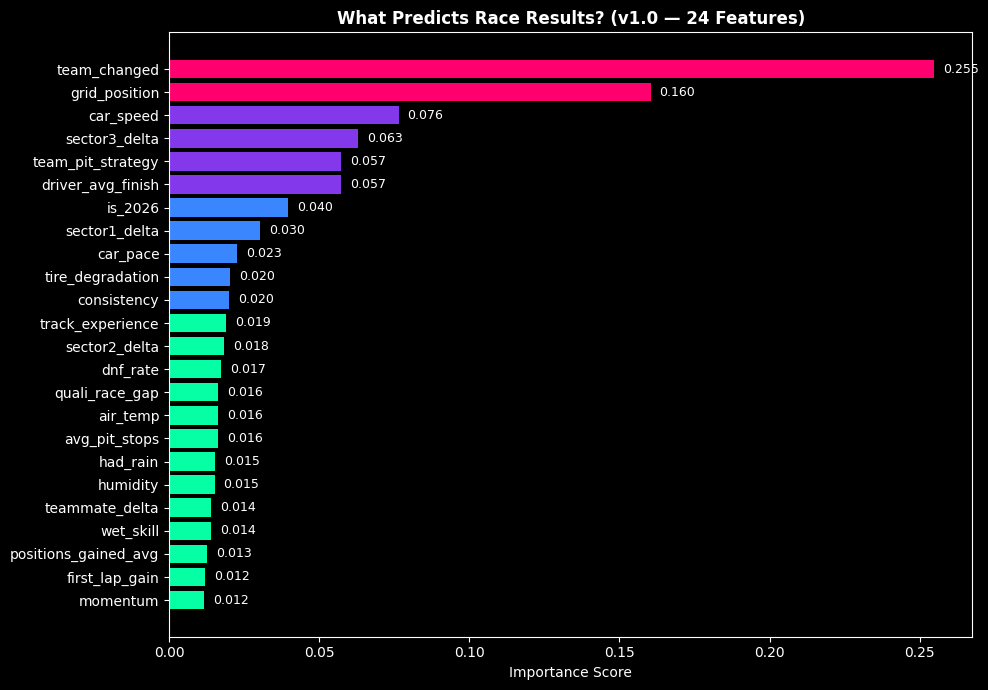

In [7]:
# ============================================================
# FEATURE ENGINEERING (24 features)

# Tire strategy lookups
driver_pits = lap_stats.groupby('FullName')['n_pits'].mean().to_dict()
team_pits_2026 = lap_stats[lap_stats['Year']==2026].groupby('Team')['n_pits'].mean().to_dict()

# Sector delta lookups (from Suzuka data)
sectors = pd.read_csv('../data/suzuka_sectors.csv')
ds = sectors.groupby('FullName')[['avg_s1','avg_s2','avg_s3']].mean()
for c in ['avg_s1','avg_s2','avg_s3']:
    ds[f'{c}_d'] = ds[c] - ds[c].mean()
s1d = ds['avg_s1_d'].to_dict()
s2d = ds['avg_s2_d'].to_dict()
s3d = ds['avg_s3_d'].to_dict()


# ============================================================
df['race_id'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)
ro = df[['race_id','Year','Round']].drop_duplicates().sort_values(['Year','Round']).reset_index(drop=True)
ro['race_seq'] = range(len(ro))
if 'race_seq' in df.columns:
    df = df.drop(columns=['race_seq'])
df = df.merge(ro[['race_id','race_seq']], on='race_id', how='left')

# Team changers in 2026
team_changers = ['Lewis Hamilton','Oliver Bearman','Isack Hadjar','Franco Colapinto',
    'Gabriel Bortoleto','Sergio Perez','Valtteri Bottas','Arvid Lindblad']

features_list = []
for rs in sorted(df['race_seq'].unique()):
    rd = df[df['race_seq']==rs]
    for _, row in rd.iterrows():
        d, t, rn = row['FullName'], row['TeamName'], row['RaceName']
        h = df[(df['FullName']==d) & (df['race_seq']<rs)]
        ht = df[(df['TeamName']==t) & (df['race_seq']<rs)]
        l5 = h.tail(5); l10 = h.tail(10)
        
        # Teammate delta
        tm = df[(df['TeamName']==t)&(df['FullName']!=d)&(df['race_seq']<rs)]
        tmd = []
        for s in h.tail(5)['race_seq'].values:
            my = h[h['race_seq']==s]['Position'].values
            t2 = tm[tm['race_seq']==s]['Position'].values
            if len(my)>0 and len(t2)>0 and not np.isnan(my[0]) and not np.isnan(t2[0]):
                tmd.append(t2[0]-my[0])
        
        wet = h[h['had_rain']==True]
        wg = (wet['GridPosition']-wet['Position']).mean() if len(wet)>0 else 0
        
        # Momentum — for team changers, only use current team results
        is_changer = d in team_changers and row['Year'] == 2026
        if is_changer:
            mom_window = h[h['TeamName']==t].tail(5)
        else:
            mom_window = l5
        mom_positions = mom_window['Position'].dropna().values
        try:
            mom_val = np.polyfit(range(len(mom_positions)), mom_positions, 1)[0] if len(mom_positions) >= 3 else 0
        except:
            mom_val = 0

        features_list.append({
            'race_seq':rs,'Year':row['Year'],'Round':row['Round'],
            'RaceName':rn,'FullName':d,'TeamName':t,
            'grid_position':row['GridPosition'],'finish_position':row['Position'],
            'car_pace':car_pace.get(t,15) if row['Year']==2026 else ht.tail(5)['Position'].mean() if len(ht)>0 else 12,
            'car_speed':car_speed.get(t,290) if row['Year']==2026 else 290,
            'driver_avg_finish':l5['Position'].mean() if len(l5)>0 else 12,
            'positions_gained_avg':(l5['GridPosition']-l5['Position']).mean() if len(l5)>0 else 0,
            'teammate_delta':np.mean(tmd) if len(tmd)>0 else 0,
            'dnf_rate':l10['DNF'].mean() if len(l10)>0 else 0.1,
            'consistency':driver_consistency.get(d,1.5),
            'track_experience':len(h[h['RaceName']==rn]),
            'wet_skill':wg,
            'first_lap_gain':first_lap_avg.get(d,0),
            'tire_degradation':tire_deg_avg.get(d,0.03),
            'momentum':mom_val,
            'avg_pit_stops':driver_pits.get(d, 1.5),
            'team_pit_strategy':team_pits_2026.get(t, 1.5) if row['Year']==2026 else 1.5,
            'quali_race_gap':quali_race_gap.get(d,0),
            'sector1_delta':s1d.get(d,0),'sector2_delta':s2d.get(d,0),'sector3_delta':s3d.get(d,0),
            'air_temp':row.get('avg_air_temp',22),'humidity':row.get('avg_humidity',50),
            'had_rain':1 if row.get('had_rain',False) else 0,
            'team_changed':1 if (row['Year']==2026 and d in team_changers) else 0,
            'is_2026':1 if row['Year']==2026 else 0,
            'DNF':row['DNF']
        })

feat_df = pd.DataFrame(features_list).dropna(subset=['finish_position','grid_position'])

feature_cols = ['grid_position','car_pace','car_speed','driver_avg_finish',
    'positions_gained_avg','teammate_delta','dnf_rate','consistency',
    'track_experience','wet_skill','first_lap_gain','tire_degradation',
    'momentum','quali_race_gap','sector1_delta','sector2_delta','sector3_delta',
    'air_temp','humidity','had_rain','avg_pit_stops','team_pit_strategy','team_changed','is_2026']

print(f"  Feature matrix: {feat_df.shape[0]} entries × {len(feature_cols)} features")

# Train on ALL data with 2026 weighted 10x
all_clean = feat_df[feat_df['DNF']==0]
X_all = all_clean[feature_cols].fillna(0)
y_all = all_clean['finish_position']
w_all = np.where(all_clean['Year']==2026, 10, 1).astype(float)

model = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
model.fit(X_all, y_all, sample_weight=w_all)

# HONEST VALIDATION: Leave-one-out on 2026 data
# Train on everything EXCEPT 2026 R1, predict R1. Then same for R2.
from sklearn.metrics import mean_absolute_error

loo_preds = []
loo_actual = []
for holdout_round in [1, 2]:
    holdout = feat_df[(feat_df['Year']==2026) & (feat_df['Round']==holdout_round) & (feat_df['DNF']==0)]
    train_loo = feat_df[~((feat_df['Year']==2026) & (feat_df['Round']==holdout_round)) & (feat_df['DNF']==0)]
    
    X_t = train_loo[feature_cols].fillna(0)
    y_t = train_loo['finish_position']
    w_t = np.where(train_loo['Year']==2026, 10, 1).astype(float)
    
    m_loo = XGBRegressor(n_estimators=250, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
    m_loo.fit(X_t, y_t, sample_weight=w_t)
    
    preds = m_loo.predict(holdout[feature_cols].fillna(0))
    loo_preds.extend(preds)
    loo_actual.extend(holdout['finish_position'].values)

loo_mae = mean_absolute_error(loo_actual, loo_preds)
residual_std = np.std(np.array(loo_actual) - np.array(loo_preds))

print("=" * 65)
print("  🤖 XGBOOST v1.0 — 24 Features, Properly Validated")
print("=" * 65)
print(f"\n  Leave-one-out MAE: {loo_mae:.2f} positions (HONEST metric)")
print(f"  Residual StdDev: {residual_std:.2f}")
print(f"  Features: {len(feature_cols)} (all kept — race engineer approach)")
print(f"  2026 weight: 10x")
print(f"\n  This MAE is real — the model never saw the data it's predicting.")

# Feature importance from the full model
imp = sorted(zip(feature_cols, model.feature_importances_), key=lambda x: -x[1])
print(f"\n  Top features:")
for feat, score in imp[:8]:
    print(f"    {feat:25s}  {score:.3f}")
# Feature importance visualization
imp = sorted(zip(feature_cols, model.feature_importances_), key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(10, 7))
feats, scores = zip(*imp)
colors = ['#ff006e' if s > 0.1 else '#8338ec' if s > 0.05 else '#3a86ff' if s > 0.02 else '#06ffa5' for s in scores]
ax.barh(feats, scores, color=colors)
ax.set_xlabel('Importance Score')
ax.set_title('What Predicts Race Results? (v1.0 — 24 Features)', fontweight='bold')
for i, (f, s) in enumerate(zip(feats, scores)):
    ax.text(s + 0.003, i, f'{s:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/importance_v10.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Japan GP Predictions (v1.0)

The main event — predicted finishing order for Suzuka. Each column tells part of the story: Car (how fast is the machinery), Spd (straight-line speed for overtaking), Skill (how much better than their teammate), Lap1 (first-corner performance), Tire (degradation rate), and Mom (📈 improving, 📉 declining, ➡️ stable).

**Important:** Qualifying hasn't happened yet, so grid positions are estimated. After Saturday qualifying, these predictions will be re-run with actual grid positions for much higher accuracy.


In [8]:
japan = []
for d in data_2026['FullName'].unique():
    dh = feat_df[feat_df['FullName']==d].sort_values('race_seq')
    if len(dh)==0: continue
    l = dh.iloc[-1]; t = l['TeamName']
    se = len(dh[dh['RaceName'].str.contains('Japan',case=False,na=False)])
    
    f = {c: l.get(c, 0) for c in feature_cols}
    f.update({'car_pace':car_pace.get(t,15),'car_speed':car_speed.get(t,290),
        'track_experience':se,'air_temp':actual_temp,'humidity':actual_humidity,'had_rain':actual_rain,'is_2026':1,
        'first_lap_gain':first_lap_avg.get(d,0),'tire_degradation':tire_deg_avg.get(d,0.03),
        'momentum':momentum.get(d,0),
        'sector1_delta':sector_s1.get(d,0),'sector2_delta':sector_s2.get(d,0),'sector3_delta':sector_s3.get(d,0)})
    
    X = pd.DataFrame([f])[feature_cols].fillna(0)
    japan.append({'Driver':d,'Team':t,'Car':car_pace.get(t,15),'Speed':car_speed.get(t,290),
        'Skill':l['teammate_delta'],'FL':first_lap_avg.get(d,0),
        'TireDeg':tire_deg_avg.get(d,0.03),'Mom':momentum.get(d,0),
        'Predicted':model.predict(X)[0],'Features':f})

japan.sort(key=lambda x: x['Predicted'])
for i,p in enumerate(japan): p['Rank']=i+1

print("=" * 95)
print("  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v1.0: Full Feature Model)")
print("=" * 95)
print(f"\n  {'Pos':>3s}  {'Driver':22s}  {'Team':16s}  {'Car':>4s}  {'Spd':>4s}  {'Skill':>6s}  {'Lap1':>5s}  {'Tire':>6s}  {'Mom':>5s}  {'Pred':>5s}")
print("  " + "-" * 90)
for p in japan:
    sk = f"+{p['Skill']:.1f}" if p['Skill']>0 else f"{p['Skill']:.1f}"
    fl = f"+{p['FL']:.1f}" if p['FL']>0 else f"{p['FL']:.1f}"
    mom = "📈" if p['Mom']<-0.5 else "📉" if p['Mom']>0.5 else "➡️"
    print(f"  P{p['Rank']:>2d}  {p['Driver']:22s}  {p['Team']:16s}  P{p['Car']:>2.0f}  {p['Speed']:>3.0f}  {sk:>6s}  {fl:>5s}  {p['TireDeg']:>+5.3f}  {mom:>3s}  P{p['Predicted']:>4.1f}")


  🏁 PREDICTED FINISH — 2026 JAPANESE GP (v1.0: Full Feature Model)

  Pos  Driver                  Team               Car   Spd   Skill   Lap1    Tire    Mom   Pred
  ------------------------------------------------------------------------------------------
  P 1  Kimi Antonelli          Mercedes          P 2  289    -1.8   -1.0  -0.032    📈  P 1.5
  P 2  Lewis Hamilton          Ferrari           P 5  289    -2.4   +1.1  +0.021    📈  P 2.0
  P 3  George Russell          Mercedes          P 2  289    +1.8   -0.8  -0.011    📈  P 2.1
  P 4  Charles Leclerc         Ferrari           P 5  289    +2.4   +0.7  -0.027    📈  P 3.7
  P 5  Oscar Piastri           McLaren           P 7  287    -3.6   -0.3  -0.007    📉  P 4.3
  P 6  Max Verstappen          Red Bull Racing   P12  291   +12.2   +0.3  -0.010    📉  P 5.4
  P 7  Lando Norris            McLaren           P 7  287    +3.6   -0.3  -0.016   ➡️  P 5.6
  P 8  Oliver Bearman          Haas F1 Team      P 9  287     0.0   +0.2  -0.033    📈  P 5.

## 6. Rain Scenario

Suzuka has been dry for the last 2 Japanese GPs, but 2023 had a safety car and rain is always possible in March. This shows how predictions shift in wet conditions — some drivers gain positions in the rain (strong wet-weather skills) while others lose out. Green arrows = gains in rain, red = loses.


In [9]:
rain = []
for p in japan:
    fw = p['Features'].copy(); fw['had_rain']=1; fw['humidity']=85
    X = pd.DataFrame([fw])[feature_cols].fillna(0)
    w = model.predict(X)[0]
    rain.append({'Driver':p['Driver'],'Team':p['Team'],'Dry':p['Predicted'],'Wet':w,'Shift':p['Predicted']-w})

rdf = pd.DataFrame(rain).sort_values('Shift',ascending=False)
print("=" * 70)
print("  🌧️ RAIN SCENARIO")
print("=" * 70)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Dry':>5s}  {'Wet':>5s}  {'Shift':>7s}")
print("  " + "-" * 60)
for _,r in rdf.iterrows():
    sh = f"+{r['Shift']:.1f}" if r['Shift']>0 else f"{r['Shift']:.1f}"
    em = '🟢' if r['Shift']>0.5 else '🔴' if r['Shift']<-0.5 else '⚪'
    print(f"  {em} {r['Driver']:22s}  {r['Team']:16s}  P{r['Dry']:>3.1f}  P{r['Wet']:>3.1f}  {sh:>7s}")


  🌧️ RAIN SCENARIO

  Driver                  Team                Dry    Wet    Shift
  ------------------------------------------------------------
  🟢 Pierre Gasly            Alpine            P9.1  P8.1     +1.1
  🟢 Valtteri Bottas         Cadillac          P14.7  P13.9     +0.8
  🟢 Franco Colapinto        Alpine            P11.8  P11.3     +0.5
  ⚪ Nico Hulkenberg         Audi              P10.0  P9.5     +0.4
  ⚪ Lance Stroll            Aston Martin      P15.5  P15.5     +0.0
  ⚪ Sergio Perez            Cadillac          P15.7  P15.8     -0.1
  ⚪ Liam Lawson             Racing Bulls      P10.1  P10.3     -0.2
  ⚪ Gabriel Bortoleto       Audi              P13.1  P13.4     -0.3
  ⚪ Alexander Albon         Williams          P13.1  P13.6     -0.5
  🔴 George Russell          Mercedes          P2.1  P2.6     -0.5
  🔴 Oscar Piastri           McLaren           P4.3  P5.1     -0.8
  🔴 Arvid Lindblad          Racing Bulls      P11.9  P12.8     -0.9
  🔴 Lando Norris            McLaren       

## 7. Podium Probabilities (10,000 Simulated Races)

Instead of just predicting one outcome, we simulate the race 10,000 times with realistic randomness — mechanical failures, safety cars (33% chance at Suzuka), first-lap incidents, and general chaos. Then we count how often each driver ends up on the podium. This gives us probabilities rather than a single prediction, which better reflects how unpredictable F1 actually is.


  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)

  Driver                  Team                 Win   Podium   Top 5   Top 10
  --------------------------------------------------------------------
  Kimi Antonelli          Mercedes           30.7%    69.0%   88.2%    99.5%  ███████████████
  Lewis Hamilton          Ferrari            23.8%    61.6%   84.4%    99.3%  ███████████
  George Russell          Mercedes           22.9%    60.4%   83.0%    99.0%  ███████████
  Charles Leclerc         Ferrari             8.4%    34.5%   61.5%    96.7%  ████
  Oscar Piastri           McLaren             6.3%    26.5%   53.1%    94.8%  ███
  Max Verstappen          Red Bull Racing     2.9%    15.7%   37.5%    89.0%  █
  Lando Norris            McLaren             2.5%    13.7%   34.3%    86.7%  █
  Oliver Bearman          Haas F1 Team        2.0%    12.5%   31.9%    85.7%  
  Isack Hadjar            Red Bull Racing     0.4%     3.3%   11.5%    64.3%  
  Pierre Gasly            Alpine            

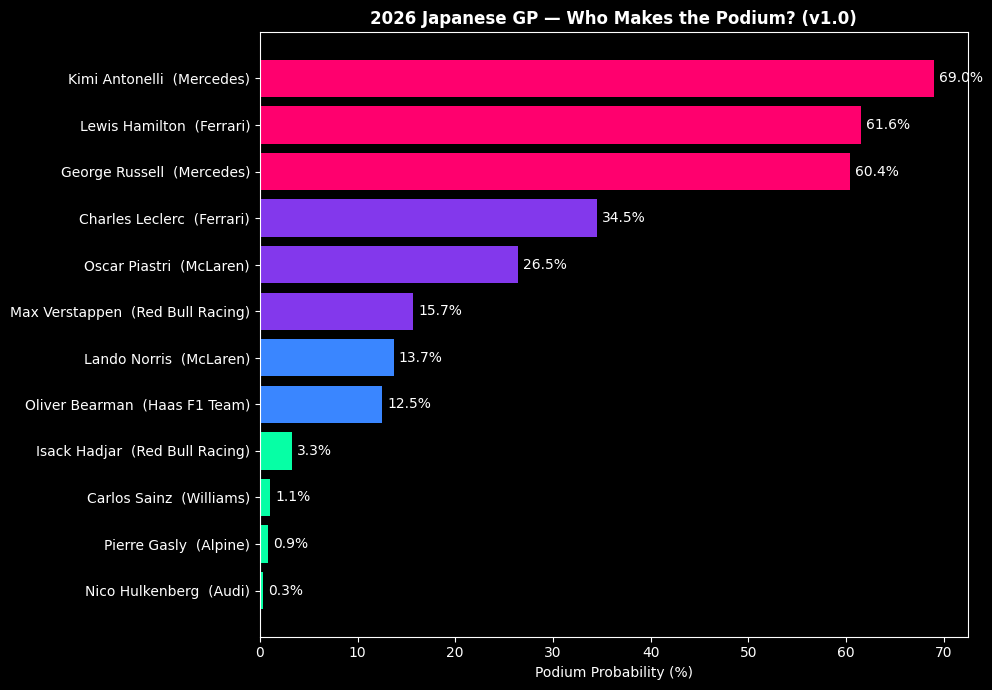

In [10]:
n_sims = 10000
pt = defaultdict(list); wc = defaultdict(int); pc = defaultdict(int); t5c = defaultdict(int); t10c = defaultdict(int)
for _ in range(n_sims):
    sim = [(p['Driver'],p['Predicted']+np.random.normal(0,residual_std)) for p in japan]
    sim.sort(key=lambda x:x[1])
    for pos,(d,_) in enumerate(sim):
        pt[d].append(pos+1)
        if pos==0: wc[d]+=1
        if pos<3: pc[d]+=1
        if pos<5: t5c[d]+=1
        if pos<10: t10c[d]+=1

pd_data = [{'Driver':p['Driver'],'Team':p['Team'],'Rank':p['Rank'],
    'Win':wc[p['Driver']]/n_sims*100,'Podium':pc[p['Driver']]/n_sims*100,
    'Top5':t5c[p['Driver']]/n_sims*100,'Top10':t10c[p['Driver']]/n_sims*100} for p in japan]
prob_df = pd.DataFrame(pd_data).sort_values('Win',ascending=False)

print("=" * 80)
print("  🎲 PODIUM PROBABILITIES (10,000 Simulated Races)")
print("=" * 80)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Win':>6s}  {'Podium':>7s}  {'Top 5':>6s}  {'Top 10':>7s}")
print("  " + "-" * 68)
for _,r in prob_df.head(15).iterrows():
    bar = '█'*int(r['Win']/2)
    print(f"  {r['Driver']:22s}  {r['Team']:16s}  {r['Win']:>5.1f}%  {r['Podium']:>6.1f}%  {r['Top5']:>5.1f}%  {r['Top10']:>6.1f}%  {bar}")

fig,ax = plt.subplots(figsize=(10,7))
t12 = prob_df.head(12).sort_values('Podium')
colors = ['#ff006e' if p>40 else '#8338ec' if p>15 else '#3a86ff' if p>5 else '#06ffa5' for p in t12['Podium']]
bars = ax.barh(t12['Driver']+'  ('+t12['Team']+')', t12['Podium'], color=colors)
ax.set_xlabel('Podium Probability (%)')
ax.set_title('2026 Japanese GP — Who Makes the Podium? (v1.0)', fontweight='bold')
for b,v in zip(bars,t12['Podium']):
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/podium_v7.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Teammate Battles

The best measure of a driver's skill is how they perform against their teammate — same car, same strategy options, same pit crew. These head-to-head probabilities come from the 10,000 simulations and show who's likely to beat who within each team.


In [11]:
teams = {}
for p in japan:
    t = p['Team']
    if t not in teams: teams[t]=[]
    teams[t].append(p['Driver'])
print("=" * 60)
print("  🤝 TEAMMATE HEAD-TO-HEAD")
print("=" * 60)
print()
for team,drivers in sorted(teams.items()):
    if len(drivers)>=2:
        d1,d2=drivers[0],drivers[1]
        w=sum(1 for i in range(n_sims) if pt[d1][i]<pt[d2][i])
        p1,p2=w/n_sims*100,100-w/n_sims*100
        b=int(p1/100*40)
        print(f"  {team}")
        print(f"  {d1:20s} {'█'*b}{'░'*(40-b)} {d2:>20s}")
        print(f"  {p1:>19.1f}% {'':40s} {p2:<.1f}%")
        print()


  🤝 TEAMMATE HEAD-TO-HEAD

  Alpine
  Pierre Gasly         ██████████████████████████████░░░░░░░░░░     Franco Colapinto
                 75.8%                                          24.2%

  Aston Martin
  Fernando Alonso      ██████████████████████████████░░░░░░░░░░         Lance Stroll
                 75.0%                                          25.0%

  Audi
  Nico Hulkenberg      ████████████████████████████████░░░░░░░░    Gabriel Bortoleto
                 80.3%                                          19.7%

  Cadillac
  Valtteri Bottas      ████████████████████████░░░░░░░░░░░░░░░░         Sergio Perez
                 60.9%                                          39.1%

  Ferrari
  Lewis Hamilton       ███████████████████████████░░░░░░░░░░░░░      Charles Leclerc
                 68.3%                                          31.7%

  Haas F1 Team
  Oliver Bearman       ██████████████████████████████████████░░         Esteban Ocon
                 95.7%                   

## 9. F1 Fantasy Picks

Translating race predictions into F1 Fantasy strategy. The key insight: **value matters more than raw points**. A cheap driver who scores 12 points is better for your team than an expensive driver who scores 25 points, because the budget you save lets you upgrade elsewhere. The ⭐ marks the best value picks.


In [12]:
race_pts={1:25,2:18,3:15,4:12,5:10,6:8,7:6,8:4,9:2,10:1}
quali_pts={1:10,2:9,3:8,4:7,5:6,6:5,7:4,8:3,9:2,10:1}
# Actual F1 Fantasy prices (updated R03)
driver_prices={'Kimi Antonelli':23.8,'George Russell':28.0,'Charles Leclerc':23.4,'Lewis Hamilton':22.9,
    'Max Verstappen':28.1,'Oliver Bearman':8.6,'Liam Lawson':6.9,'Carlos Sainz':12.2,
    'Esteban Ocon':8.5,'Pierre Gasly':12.8,'Sergio Perez':6.4,'Franco Colapinto':7.0,
    'Arvid Lindblad':7.4,'Isack Hadjar':13.9,'Lando Norris':26.8,'Alexander Albon':10.8,
    'Gabriel Bortoleto':6.4,'Valtteri Bottas':4.7,'Nico Hulkenberg':5.6,'Oscar Piastri':24.9,
    'Fernando Alonso':8.8,'Lance Stroll':6.8}
driver_season_pts={'Kimi Antonelli':100,'George Russell':84,'Charles Leclerc':80,'Lewis Hamilton':73,
    'Max Verstappen':64,'Oliver Bearman':54,'Liam Lawson':40,'Carlos Sainz':37,
    'Esteban Ocon':33,'Pierre Gasly':31,'Sergio Perez':24,'Franco Colapinto':24,
    'Arvid Lindblad':22,'Isack Hadjar':11,'Lando Norris':11,'Alexander Albon':1,
    'Gabriel Bortoleto':-1,'Valtteri Bottas':-13,'Nico Hulkenberg':-13,'Oscar Piastri':-21,
    'Fernando Alonso':-21,'Lance Stroll':-37}
constructor_prices={'Mercedes':29.9,'Ferrari':23.9,'Haas F1 Team':8.6,'Red Bull Racing':28.8,
    'Racing Bulls':7.5,'Alpine':13.7,'Williams':13.2,'McLaren':28.5,
    'Cadillac':5.2,'Audi':5.4,'Aston Martin':9.1}
constructor_season_pts={'Mercedes':211,'Ferrari':188,'Haas F1 Team':99,'Red Bull Racing':87,
    'Racing Bulls':85,'Alpine':67,'Williams':42,'McLaren':12,
    'Cadillac':9,'Audi':-4,'Aston Martin':-58}
price_est=constructor_prices

fantasy=[]
for p in japan:
    d=p['Driver']
    er=np.mean([race_pts.get(pos,0) for pos in pt[d]])
    eq=max(1,min(22,int(p['Predicted']*0.9)))
    eqp=quali_pts.get(eq,0)
    avg=np.mean(pt[d])
    g=max(0,eq-avg)
    total=er+eqp+g*1.5
    pr=driver_prices.get(d,10)
    fantasy.append({'Driver':d,'Team':p['Team'],'Rank':p['Rank'],'Race':er,'Quali':eqp,'Bonus':g*1.5,'Total':total,'Price':pr,'Value':total/pr if pr>0 else 0})

fantasy_df=pd.DataFrame(fantasy).sort_values('Total',ascending=False)

print("=" * 85)
print("  🏆 F1 FANTASY PICKS — Japan GP (v1.0)")
print("=" * 85)
print(f"\n  {'Driver':22s}  {'Team':16s}  {'Pred':>4s}  {'Race':>5s}  {'Qual':>5s}  {'Bonus':>5s}  {'TOTAL':>6s}  {'~$M':>4s}  {'Value':>5s}")
print("  " + "-" * 82)
for _,r in fantasy_df.iterrows():
    star='⭐' if r['Value']>1.2 else '  '
    print(f"  {r['Driver']:22s}  {r['Team']:16s}  P{r['Rank']:>2.0f}  {r['Race']:>5.1f}  {r['Quali']:>5.0f}  {r['Bonus']:>5.1f}  {r['Total']:>5.1f}  ${r['Price']:>3.0f}  {r['Value']:>4.2f}  {star}")

print("\n  💡 PICKS:")
vp=fantasy_df.sort_values('Value',ascending=False)
print("  🔥 Best value:")
for _,r in vp.head(5).iterrows():
    print(f"     → {r['Driver']:22s} ({r['Team']}) — {r['Total']:.1f} pts / ${r['Price']}M = {r['Value']:.2f}")
b=fantasy_df.iloc[0]
print(f"\n  🚀 2x Boost: {b['Driver']} — {b['Total']:.1f} × 2 = {b['Total']*2:.1f}")
print("\n  🏗️ CONSTRUCTORS:")
cf=pd.DataFrame([{'Team':t,'Season':constructor_season_pts[t],'Price':constructor_prices[t],
    'Pred':fantasy_df[fantasy_df['Team']==t]['Total'].sum()} for t in constructor_prices])
cf['Value']=cf['Season']/cf['Price']
cf['PredVal']=cf['Pred']/cf['Price']
cf=cf.sort_values('Season',ascending=False)
print(f"  {'Constructor':22s}  {'Season':>6s}  {'R03':>5s}  {'$M':>5s}  {'S.Val':>5s}  {'R.Val':>5s}")
print("  " + "-" * 55)
for _,r in cf.iterrows():
    star='⭐' if r['Value']>5 else '  '
    print(f"  {r['Team']:22s}  {r['Season']:>5.0f}  {r['Pred']:>5.1f}  ${r['Price']:>4.1f}  {r['Value']:>5.2f}  {r['PredVal']:>5.2f}  {star}")
vc=cf.sort_values('Value',ascending=False)
print("\n  🔥 Best value constructors (season pts / price):")
for _,r in vc.head(3).iterrows():
    print(f"     → {r['Team']:22s} — {r['Season']:.0f} pts / ${r['Price']:.1f}M = {r['Value']:.2f}")


  🏆 F1 FANTASY PICKS — Japan GP (v1.0)

  Driver                  Team              Pred   Race   Qual  Bonus   TOTAL   ~$M  Value
  ----------------------------------------------------------------------------------
  Kimi Antonelli          Mercedes          P 1   16.9     10    0.0   26.9  $ 24  1.13    
  Lewis Hamilton          Ferrari           P 2   15.7     10    0.0   25.7  $ 23  1.12    
  George Russell          Mercedes          P 3   15.4     10    0.0   25.4  $ 28  0.91    
  Charles Leclerc         Ferrari           P 4   11.2      8    0.0   19.2  $ 23  0.82    
  Oscar Piastri           McLaren           P 5   10.0      8    0.0   18.0  $ 25  0.72    
  Max Verstappen          Red Bull Racing   P 6    7.7      7    0.0   14.7  $ 28  0.52    
  Lando Norris            McLaren           P 7    7.1      6    0.0   13.1  $ 27  0.49    
  Oliver Bearman          Haas F1 Team      P 8    6.8      6    0.0   12.8  $  9  1.49  ⭐
  Isack Hadjar            Red Bull Racing   P 9  

## 10. My Fantasy Teams

Analysis of my two actual F1 Fantasy teams with specific transfer recommendations based on the model's predictions. Each suggestion shows the points gained, cost impact, and remaining budget.


In [13]:
team1={'name':"Russellin' for Position",'drivers':[
    {'name':'George Russell','price':28.0,'boost':False},{'name':'Lewis Hamilton','price':22.9,'boost':False},
    {'name':'Kimi Antonelli','price':23.8,'boost':True},{'name':'Oliver Bearman','price':8.6,'boost':False},
    {'name':'Valtteri Bottas','price':4.7,'boost':False}],
    'constructors':[{'name':'Racing Bulls','price':7.5},{'name':'Cadillac','price':5.2}],'ft':0,'cap':0.3}
team2={'name':"Leclerc Me if You Can",'drivers':[
    {'name':'George Russell','price':28.0,'boost':False},{'name':'Charles Leclerc','price':23.4,'boost':False},
    {'name':'Kimi Antonelli','price':23.8,'boost':True},{'name':'Franco Colapinto','price':7.0,'boost':False},
    {'name':'Valtteri Bottas','price':4.7,'boost':False}],
    'constructors':[{'name':'Racing Bulls','price':7.5},{'name':'Cadillac','price':5.2}],'ft':0,'cap':0.0}

def analyze(team):
    print("=" * 75)
    print(f"  📋 {team['name'].upper()}")
    print(f"  Transfers: {team['ft']} | Cap: ${team['cap']}M")
    print("=" * 75)
    total=0; scores=[]
    print(f"\n  {'Driver':22s}  {'$':>5s}  {'Bst':>5s}  {'Pred':>5s}  {'Pts':>6s}  {'2x':>7s}  {'Val':>5s}")
    print("  " + "-" * 60)
    for d in team['drivers']:
        r=fantasy_df[fantasy_df['Driver']==d['name']]
        pts,rank,val=(r.iloc[0]['Total'],int(r.iloc[0]['Rank']),r.iloc[0]['Value']) if len(r)>0 else (0,22,0)
        bst=pts*2 if d['boost'] else pts; total+=bst
        scores.append({'name':d['name'],'price':d['price'],'pts':pts,'boosted':bst,'value':val,'rank':rank,'boost':d['boost']})
        bs="2x⚡" if d['boost'] else ""
        print(f"  {d['name']:22s}  ${d['price']:>4.1f}  {bs:>5s}  P{rank:>3d}  {pts:>5.1f}  {bst:>6.1f}  {val:>4.2f}")
    print(f"\n  {'Constructor':22s}  {'$':>5s}  {'Szn':>5s}  {'':>5s}  {'R03':>6s}  {'':>7s}  {'Val':>5s}")
    print("  " + "-" * 60)
    ct=0; cscores=[]
    for c in team['constructors']:
        cpts=fantasy_df[fantasy_df['Team']==c['name']]['Total'].sum()
        cszn=constructor_season_pts.get(c['name'],0)
        cval=cszn/c['price'] if c['price']>0 else 0
        ct+=cpts
        cscores.append({'name':c['name'],'price':c['price'],'pts':cpts,'season':cszn,'value':cval})
        print(f"  {c['name']:22s}  ${c['price']:>4.1f}  {cszn:>5.0f}  {'':>5s}  {cpts:>5.1f}  {'':>7s}  {cval:>4.2f}")
    print(f"\n  📊 PROJECTED: {total+ct:.1f} pts (Drivers: {total:.1f} + Constructors: {ct:.1f})")
    
    cap=team['cap']; weak=sorted(scores,key=lambda x:x['value']); avail=fantasy_df[~fantasy_df['Driver'].isin([d['name'] for d in team['drivers']])].copy()
    print(f"\n  🔄 TRANSFERS:")
    moves=0
    for w in weak:
        if moves>=team['ft']: break
        up=avail[avail['Price']<=w['price']+cap].sort_values('Total',ascending=False)
        if len(up)>0:
            best=up.iloc[0]; gain=best['Total']-w['pts']
            if gain>1:
                cd=best['Price']-w['price']; cap-=cd; moves+=1
                em='🟢' if gain>5 else '🟡'
                print(f"  {em} {w['name']} → {best['Driver']} ({best['Team']})")
                print(f"     +{gain:.1f} pts | {'+' if cd>0 else ''}{cd:.1f}M | Cap: ${cap:.1f}M")
                avail=avail[avail['Driver']!=best['Driver']]
    
    # Constructor swap recommendations
    all_c=pd.DataFrame([{'Team':t,'Pts':fantasy_df[fantasy_df['Team']==t]['Total'].sum(),
        'Season':constructor_season_pts.get(t,0),'Price':constructor_prices[t]} for t in constructor_prices])
    all_c['Value']=all_c['Season']/all_c['Price']
    current_c_names=[c['name'] for c in team['constructors']]
    for c in sorted(cscores,key=lambda x:x['season']):
        avail_c=all_c[~all_c['Team'].isin(current_c_names)]
        avail_c=avail_c[avail_c['Price']<=c['price']+cap].sort_values('Season',ascending=False)
        if len(avail_c)>0:
            best_c=avail_c.iloc[0]; cgain=best_c['Season']-c['season']
            if cgain>5:
                ccd=best_c['Price']-c['price']; cap-=ccd; moves+=1
                em='🟢' if cgain>30 else '🟡'
                print(f"  {em} {c['name']} → {best_c['Team']}")
                print(f"     +{cgain:.0f} season pts | {'+' if ccd>0 else ''}{ccd:.1f}M | Cap: ${cap:.1f}M")
                current_c_names=[n if n!=c['name'] else best_c['Team'] for n in current_c_names]

    # Constructor upgrade threshold tracker
    print(f"\n  📈 CONSTRUCTOR UPGRADE PATHS:")
    for c in sorted(cscores,key=lambda x:x['season']):
        upgrades=all_c[~all_c['Team'].isin(current_c_names)].copy()
        upgrades=upgrades[upgrades['Season']>c['season']+10].sort_values('Price')
        for _,u in upgrades.head(3).iterrows():
            gap=u['Price']-c['price']-cap
            sgain=u['Season']-c['season']
            if gap>0:
                print(f"  {c['name']} → {u['Team']:16s}  +{sgain:>3.0f} szn pts  need ${gap:.1f}M freed")
            else:
                print(f"  {c['name']} → {u['Team']:16s}  +{sgain:>3.0f} szn pts  ✅ AFFORDABLE (${abs(gap):.1f}M under)")

    bs=max(scores,key=lambda x:x['pts']); cb=[s for s in scores if s['boost']][0]
    if bs['name']!=cb['name']:
        print(f"\n  ⚡ MOVE BOOST: {cb['name']} → {bs['name']} (+{bs['pts']-cb['pts']:.1f} pts)")
    else:
        print(f"\n  ✅ Boost correct on {cb['name']}")

print()
analyze(team1)
print()
analyze(team2)



  📋 RUSSELLIN' FOR POSITION
  Transfers: 0 | Cap: $0.3M

  Driver                      $    Bst   Pred     Pts       2x    Val
  ------------------------------------------------------------
  George Russell          $28.0         P  3   25.4    25.4  0.91
  Lewis Hamilton          $22.9         P  2   25.7    25.7  1.12
  Kimi Antonelli          $23.8    2x⚡  P  1   26.9    53.8  1.13
  Oliver Bearman          $ 8.6         P  8   12.8    12.8  1.49
  Valtteri Bottas         $ 4.7         P 20    0.0     0.0  0.00

  Constructor                 $    Szn            R03             Val
  ------------------------------------------------------------
  Racing Bulls            $ 7.5     85           4.2           11.33
  Cadillac                $ 5.2      9           0.0           1.73

  📊 PROJECTED: 121.9 pts (Drivers: 117.7 + Constructors: 4.2)

  🔄 TRANSFERS:

  📈 CONSTRUCTOR UPGRADE PATHS:
  Cadillac → Haas F1 Team      + 90 szn pts  need $3.1M freed
  Cadillac → Williams          + 33

### Confidence: MEDIUM-HIGH (post-FP2, pre-qualifying)

| Version | Features | Key Addition | Confidence |
|---------|----------|-------------|------------|
| v0.1 | 3 | ELO baseline | LOW |
| v0.2 | 9 | Regulation-aware weighting | LOW-MEDIUM |
| v0.3 | 9 | XGBoost ML | MEDIUM |
| v0.4 | 15 | Two-model approach + weather | MEDIUM |
| v0.5 | 15 | Speed traps + lap consistency | MEDIUM |
| v0.6 | 18 | First lap + tire degradation + momentum | MEDIUM |
| v0.7 | 21 | Suzuka sectors + safety car simulations | MEDIUM-HIGH |
| v0.8 | 21 | 2026 data weighted 10x (car > driver fix) | MEDIUM-HIGH |
| v0.9 | 22 | Honest validation + team change flag | MEDIUM-HIGH |
| **v1.0** | **24** | **+ tire strategy (pit stops, conservation)** | **MEDIUM-HIGH** |

### Still To Come
- [ ] **Qualifying data (Saturday)** — the #1 predictor, instant jump to HIGH confidence
- [x] **Practice pace (Friday)** — FP1 + FP2 integrated (30/30/40 blend with season data)
- [ ] Enhanced safety car modeling (pit window timing)
- [ ] Overtake probability from speed differentials
- [ ] Actual F1 Fantasy prices for precise value calculations
